In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import joblib

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
print("All Libraries Imported Successfully ✅")

All Libraries Imported Successfully ✅


In [ ]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

In [ ]:
print(stop_words)

print(type(stemmer))

print(type(lemmatizer))

{'haven', 'just', "it'll", 'there', 'it', 'will', "didn't", 'of', 'are', 'few', 'ourselves', 'which', "wouldn't", "needn't", 'him', "you'll", 'if', "isn't", 'with', 'herself', 'other', "wasn't", 'by', "they're", 'further', 'were', 'our', 'under', 'same', "you'd", 'do', 'in', 'be', 'yourself', 'should', 'd', "shouldn't", 'didn', 'needn', "don't", "we'll", 'for', 'not', "it's", 'most', 'both', 'wouldn', 'is', 'any', 'hasn', 'between', 'up', "hadn't", 'their', 'am', 'y', 't', 'on', "he'd", "couldn't", 'shouldn', 'couldn', 'some', 'its', 'had', 'my', 'themselves', 'how', 'now', "we've", 'over', 'this', "he'll", "i've", "mightn't", 'and', 'can', 'so', 'from', 'where', 'won', 'why', "they've", 'his', 'into', 'to', 'once', 'we', 's', 'at', 'does', 'ain', 'shan', 'when', 'here', 'doing', "hasn't", 'hers', "i'm", 'have', "i'd", "it'd", "she's", 'm', "won't", 'an', 'through', 'what', 'ma', 'weren', 'then', 'or', 'until', "he's", 'whom', 'don', 'she', "we'd", 'you', "you've", "she'll", "we're", '

In [ ]:
import pandas as pd
import zipfile
import os

In [ ]:
zip_path = "/content/Sentiment.zip"

extract_path = "/content/Sentiment"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully ✅")

Dataset Extracted Successfully ✅


In [ ]:
os.listdir(extract_path)

['IMDB Dataset.csv']

In [ ]:
csv_file = None

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)

print(csv_file)

/content/Sentiment/IMDB Dataset.csv


In [ ]:
df = pd.read_csv(csv_file)

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [ ]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(50000, 2)


In [ ]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 418


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
df['sentiment'].value_counts(normalize=True) * 100

,proportion
sentiment,
positive,50.0
negative,50.0


In [23]:
df.describe(include='all')

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [24]:
df['review_length'] = df['review'].astype(str).apply(len)

df['review_length'].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


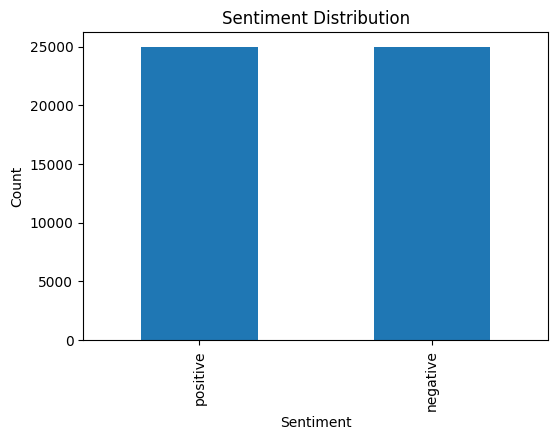

In [25]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [26]:
import re
import string

In [27]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [28]:
df['clean_review'] = df['review'].apply(clean_text)

In [29]:
print(df.columns)

Index(['review', 'sentiment', 'review_length', 'clean_review'], dtype='object')


In [30]:
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [31]:
df['clean_review'].isnull().sum()

np.int64(0)

In [32]:
(df['clean_review'] == '').sum()

np.int64(0)

In [33]:
df.to_csv("/content/cleaned_sentiment.csv", index=False)

print("Cleaned dataset saved successfully ✅")

Cleaned dataset saved successfully ✅


In [34]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [35]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

In [36]:
def preprocess_text(text):

    # Tokenization
    words = word_tokenize(text)

    # Stopword Removal
    words = [word for word in words if word not in stop_words]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [38]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [39]:
df['processed_review'] = df['clean_review'].apply(preprocess_text)

In [40]:
df[['review', 'clean_review', 'processed_review']].head()

,review,clean_review,processed_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one review mention watch oz episod youll hook ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...,petter mattei love time money visual stun film...


In [41]:
df['processed_review'].isnull().sum()

np.int64(0)

In [42]:
(df['processed_review'] == '').sum()

np.int64(0)

In [43]:
df.to_csv("/content/processed_sentiment.csv", index=False)

print("Processed dataset saved successfully ✅")

Processed dataset saved successfully ✅


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [45]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [46]:
X = tfidf.fit_transform(df['processed_review'])

In [47]:
y = df['sentiment']

In [51]:
print(X.shape)

(50000, 5000)


In [48]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['abandon' 'abc' 'abil' 'abl' 'absenc' 'absolut' 'absolut noth' 'absorb'
 'absurd' 'abus' 'abysm' 'academi' 'academi award' 'accent' 'accept'
 'access' 'accid' 'accident' 'acclaim' 'accompani' 'accomplish' 'accord'
 'account' 'accur' 'accus' 'achiev' 'acknowledg' 'acquir' 'across' 'act']


In [49]:
tfidf_df = pd.DataFrame(
    X[:5].toarray(),
    columns=feature_names
)

tfidf_df.iloc[:, :10]

,abandon,abc,abil,abl,absenc,absolut,absolut noth,absorb,absurd,abus
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
import joblib

joblib.dump(tfidf, "/content/vectorizer.pkl")

print("TF-IDF Vectorizer Saved Successfully ✅")

TF-IDF Vectorizer Saved Successfully ✅


In [52]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [54]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (40000, 5000)
Testing Features  : (10000, 5000)
Training Labels   : (40000,)
Testing Labels    : (10000,)


In [55]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Trained Successfully ✅")

Logistic Regression Trained Successfully ✅


In [56]:
lr_predictions = lr_model.predict(X_test)

In [57]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8873


In [58]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes Trained Successfully ✅")

Naive Bayes Trained Successfully ✅


In [59]:
nb_predictions = nb_model.predict(X_test)

In [60]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.8551


In [61]:
print("=" * 40)
print("Model Comparison")
print("=" * 40)

print(f"Logistic Regression : {lr_accuracy:.4f}")

print(f"Naive Bayes         : {nb_accuracy:.4f}")

Model Comparison
Logistic Regression : 0.8873
Naive Bayes         : 0.8551


In [62]:
if lr_accuracy > nb_accuracy:
    best_model = lr_model
    print("✅ Best Model: Logistic Regression")
else:
    best_model = nb_model
    print("✅ Best Model: Naive Bayes")

✅ Best Model: Logistic Regression


In [63]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [64]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [65]:
cm = confusion_matrix(y_test, lr_predictions)

print(cm)

[[4394  606]
 [ 521 4479]]


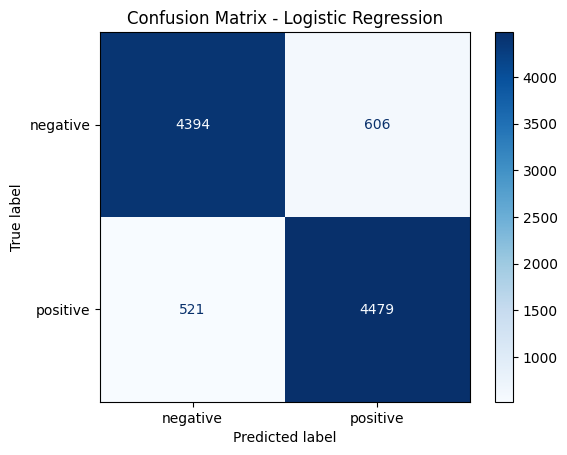

In [66]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [67]:
print(f"Accuracy: {lr_accuracy * 100:.2f}%")

Accuracy: 88.73%


In [68]:
import joblib

In [69]:
joblib.dump(lr_model, "model.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅


In [70]:
joblib.dump(tfidf, "vectorizer.pkl")

print("Vectorizer saved successfully ✅")

Vectorizer saved successfully ✅


In [71]:
import os

print(os.listdir())

['.config', 'vectorizer.pkl', 'processed_sentiment.csv', 'Sentiment', 'model.pkl', 'cleaned_sentiment.csv', 'Sentiment.zip', 'sample_data']


In [72]:
loaded_model = joblib.load("model.pkl")

loaded_vectorizer = joblib.load("vectorizer.pkl")

print("Files Loaded Successfully ✅")

Files Loaded Successfully ✅


In [73]:
sample = [
    "I absolutely loved this movie. It was fantastic!"
]

sample_vector = loaded_vectorizer.transform(sample)

prediction = loaded_model.predict(sample_vector)

print(prediction)

['positive']


In [74]:
sample = [
    "This movie was boring and a complete waste of time."
]

sample_vector = loaded_vectorizer.transform(sample)

prediction = loaded_model.predict(sample_vector)

print(prediction)

['positive']


In [75]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
import os

print(os.listdir("/content"))

['.config', 'vectorizer.pkl', 'processed_sentiment.csv', 'Sentiment', 'model.pkl', 'cleaned_sentiment.csv', 'Sentiment.zip', 'sample_data']


In [77]:
import os

print("Model Size:", os.path.getsize("/content/model.pkl"))
print("Vectorizer Size:", os.path.getsize("/content/vectorizer.pkl"))

Model Size: 41023
Vectorizer Size: 183597


In [78]:
from google.colab import files

files.download("/content/model.pkl")
files.download("/content/vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>